In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

df = pd.read_csv("/content/StockPriceDataset.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]

print(data.head())

                Close
Date                 
2014-01-02  19.754642
2014-01-03  19.320715
2014-01-06  19.426071
2014-01-07  19.287144
2014-01-08  19.409286


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [4]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [10]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
628/628 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - loss: 0.0011
Epoch 2/5
628/628 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - loss: 3.4522e-04
Epoch 3/5
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - loss: 2.4727e-04
Epoch 4/5
628/628 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - loss: 2.2313e-04
Epoch 5/5
628/628 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - loss: 1.8176e-04


In [7]:
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


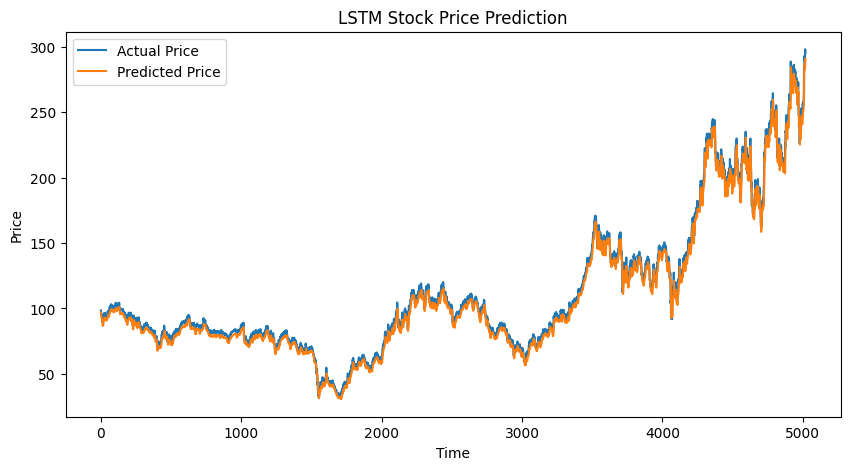

In [8]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title("LSTM Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 4.319980201248582
